# Evaluate mock community classification accuracy
The purpose of this notebook is to evaluate taxonomic classification accuracy of mock communities using different classification methods.

Prepare the environment
-----------------------

First we'll import various functions that we'll need for generating the report. 

In [41]:
%matplotlib inline

from os import environ
from os.path import join, exists, expandvars
import pandas as pd
from IPython.display import display

from tax_credit.plotting_functions import (pointplot_from_data_frame,
                                           boxplot_from_data_frame,
                                           heatmap_from_data_frame,)
from tax_credit.framework_functions import (per_level_kruskal_wallis)
from tax_credit.eval_framework import (evaluate_results,
                                       method_by_dataset_a1,
                                       method_by_dataset_a2,
                                       parameter_comparisons,
                                       method_by_dataset)

Configure local environment-specific values
-------------------------------------------

**This is the only cell that you will need to edit to generate basic reports locally.** After editing this cell, you can run all cells in this notebook to generate your analysis report. This will take a few minutes to run, as results are computed at multiple taxonomic levels.

Values in this cell will not need to be changed, with the exception of ``project_dir``, to generate the default results contained within tax-credit. To analyze results separately from the tax-credit precomputed results, other variables in this cell will need to be set.

In [4]:
## project_dir should be the directory where you've downloaded (or cloned) the 
## short-read-tax-assignment repository. 
project_dir = expandvars("$HOME/Desktop/projects/short-read-tax-assignment")

## precomputed_results_dir is the directory containing taxonomy assignment
## results to compare. Defaults to the precomputed results in tax-credit
precomputed_results_dir = join(project_dir, "data/precomputed-results/")

## expected_results_dir contains expected composition data in the structure
## expected_results_dir/<dataset name>/<reference name>/expected/
expected_results_dir = join(precomputed_results_dir, "mock-community")

## mock_results_fp designates the files to which summary results are written.
## If this file exists, it can be read in to generate results plots, instead
## of computing new scores.
mock_results_fp = join(expected_results_dir, 'mock_results.tsv')

## results_dirs should contain the directory or directories where
## results can be found. By default, this is just the precomputed 
## results included with the project. If other results should be included, 
## absolute paths to those directories should be added to this list.
results_dirs = [precomputed_results_dir]

## Minimum number of times an OTU must be observed for it to be included in analyses. Edit this
## to analyze the effect of the minimum count on taxonomic results.
min_count = 1

## Define the range of taxonomic levels over which to compute accuracy scores.
## The default given below will compute order (level 2) through species (level 6)
taxonomy_level_range = range(2,7)

Find mock community pre-computed tables, expected tables, and "query" tables
----------------------------------------------------------------------------

Next we'll use the paths defined above to find all of the tables that will be compared. These include the *pre-computed result* tables (i.e., the ones that the new methods will be compared to), the *expected result* tables (i.e., the tables containing the known composition of the mock microbial communities), and the *query result* tables (i.e., the tables generated with the new method(s) that we want to compare to the *pre-computed result* tables).

In [11]:
mock_results = evaluate_results(results_dirs, 
                                expected_results_dir, 
                                mock_results_fp, 
                                taxonomy_level_range=range(2,7), 
                                min_count=1,
                                taxa_to_keep=None, 
                                md_key='taxonomy', 
                                subsample=False,
                                force=False)

/Users/nbokulich/Desktop/projects/short-read-tax-assignment/data/precomputed-results/mock-community/mock_results.tsv already exists.
Reading in pre-computed evaluation results.
To overwrite, set force=True


In [7]:
mock_results

,Dataset,Level,SampleID,Reference,Method,Parameters,Precision,Recall,F-measure,Pearson r,Pearson p,Spearman r,Spearman p,best N alignments,confidence,coverage,e value,max accepts,min consensus fraction,similarity
0,mock-1,2,MockHiSeq.even,gg_13_8_otus,rdp,0.0,0.666667,1.000000,0.800000,0.734813,0.006483,0.743537,5.573571e-03,NaN,"[0.0, '.', 0.0]",NaN,NaN,NaN,NaN,NaN
1,mock-1,3,MockHiSeq.even,gg_13_8_otus,rdp,0.0,0.533333,1.000000,0.695652,0.688376,0.004548,0.728961,2.048126e-03,NaN,"[0.0, '.', 0.0]",NaN,NaN,NaN,NaN,NaN
2,mock-1,4,MockHiSeq.even,gg_13_8_otus,rdp,0.0,0.521739,0.923077,0.666667,0.498124,0.013241,0.665204,3.899569e-04,NaN,"[0.0, '.', 0.0]",NaN,NaN,NaN,NaN,NaN
3,mock-1,5,MockHiSeq.even,gg_13_8_otus,rdp,0.0,0.527778,0.730769,0.612903,0.272111,0.077522,0.165207,2.897312e-01,NaN,"[0.0, '.', 0.0]",NaN,NaN,NaN,NaN,NaN
4,mock-1,6,MockHiSeq.even,gg_13_8_otus,rdp,0.0,0.250000,0.342857,0.289157,-0.098744,0.412634,-0.493691,1.214887e-05,NaN,"[0.0, '.', 0.0]",NaN,NaN,NaN,NaN,NaN
325,mock-10,2,Mock.1,unite_20.11.2016,rdp,0.0,0.750000,1.000000,0.857143,0.762238,0.237762,0.632456,3.675445e-01,NaN,"[0.0, '.', 0.0]",NaN,NaN,NaN,NaN,NaN
326,mock-10,2,Mock.2,unite_20.11.2016,rdp,0.0,0.750000,1.000000,0.857143,0.793956,0.206044,0.948683,5.131670e-02,NaN,"[0.0, '.', 0.0]",NaN,NaN,NaN,NaN,NaN
327,mock-10,2,Mock.3,unite_20.11.2016,rdp,0.0,0.750000,1.000000,0.857143,0.725565,0.274435,0.632456,3.675445e-01,NaN,"[0.0, '.', 0.0]",NaN,NaN,NaN,NaN,NaN
328,mock-10,3,Mock.1,unite_20.11.2016,rdp,0.0,0.800000,1.000000,0.888889,0.415554,0.486549,0.447214,4.501849e-01,NaN,"[0.0, '.', 0.0]",NaN,NaN,NaN,NaN,NaN
329,mock-10,3,Mock.2,unite_20.11.2016,rdp,0.0,0.800000,1.000000,0.888889,0.458658,0.437194,0.447214,4.501849e-01,NaN,"[0.0, '.', 0.0]",NaN,NaN,NaN,NaN,NaN


Restrict analyses to a set of datasets or references: e.g., exclude taxonomy assignments made for purpose of reference database comparisons.

In [12]:
mock_results = mock_results[mock_results['Reference'].isin(['gg_13_8_otus', 'unite_20.11.2016'])]
#mock_results = mock_results[mock_results['Reference'] != 'gg_13_8_otus_trim150']
#mock_results = mock_results[mock_results['Reference'] != 'gg_13_8_otus_full16S']

Evalution 1: Compute and summarize precision, recall, and F-measure for mock communities
----------------------------------------------------------------------------------------

In this evaluation, we compute and summarize precision, recall, and F-measure of each result (pre-computed and query) based on the known composition of the mock communities. We then summarize the results in two ways: first with boxplots, and second with a table of the top methods based on their F-measures. 

This is a qualitative evaluation, effectively telling us about the ability of the different methods to report the taxa that are present in each sample. These metrics are not concerned with the abundance of the different taxa.

As a first step, we will evaluate how accuracy metrics perform at each taxonomic level for each method within each reference dataset type.

In [13]:
color_pallette = dict(rdp="seagreen", sortmerna="gray", uclust="blue")

y_vars = ["Precision", "Recall", "F-measure"]

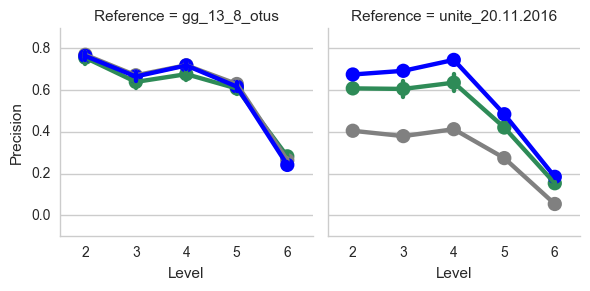

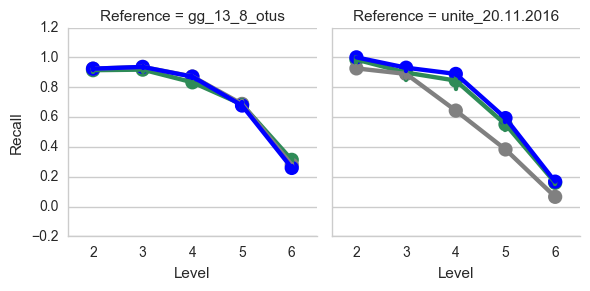

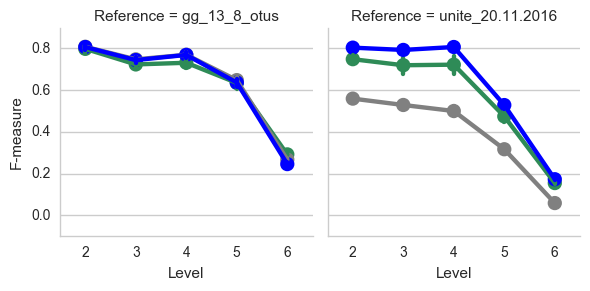

In [14]:
pointplot_from_data_frame(mock_results, "Level", y_vars, 
                          group_by="Reference", color_by="Method",
                          color_pallette=color_pallette)

Kruskal-Wallis FDR-corrected p-values comparing classification methods at each level of taxonomic assignment

In [15]:
result = per_level_kruskal_wallis(mock_results, y_vars, group_by='Method', 
                                  dataset_col='Reference', level_name='Level',
                                  levelrange=range(2,7), alpha=0.05, 
                                  pval_correction='fdr_bh')
result

,Dataset,Variable,2,3,4,5,6
0,gg_13_8_otus,Precision,9.889976e-02,5.590507e-02,7.378461e-05,1.500012e-01,1.395491e-05
1,gg_13_8_otus,Recall,6.375559e-01,1.855295e-01,1.518855e-02,2.103505e-01,1.579713e-08
2,gg_13_8_otus,F-measure,1.298837e-01,1.087429e-03,4.681557e-07,2.052143e-01,5.210654e-09
3,unite_20.11.2016,Precision,5.177107e-55,4.302460e-52,1.609214e-48,5.437493e-34,1.001905e-47
4,unite_20.11.2016,Recall,2.490194e-08,9.380811e-01,1.690821e-19,3.543678e-16,2.534046e-36
5,unite_20.11.2016,F-measure,2.145188e-54,8.908420e-36,1.881793e-42,1.341044e-22,1.439505e-46


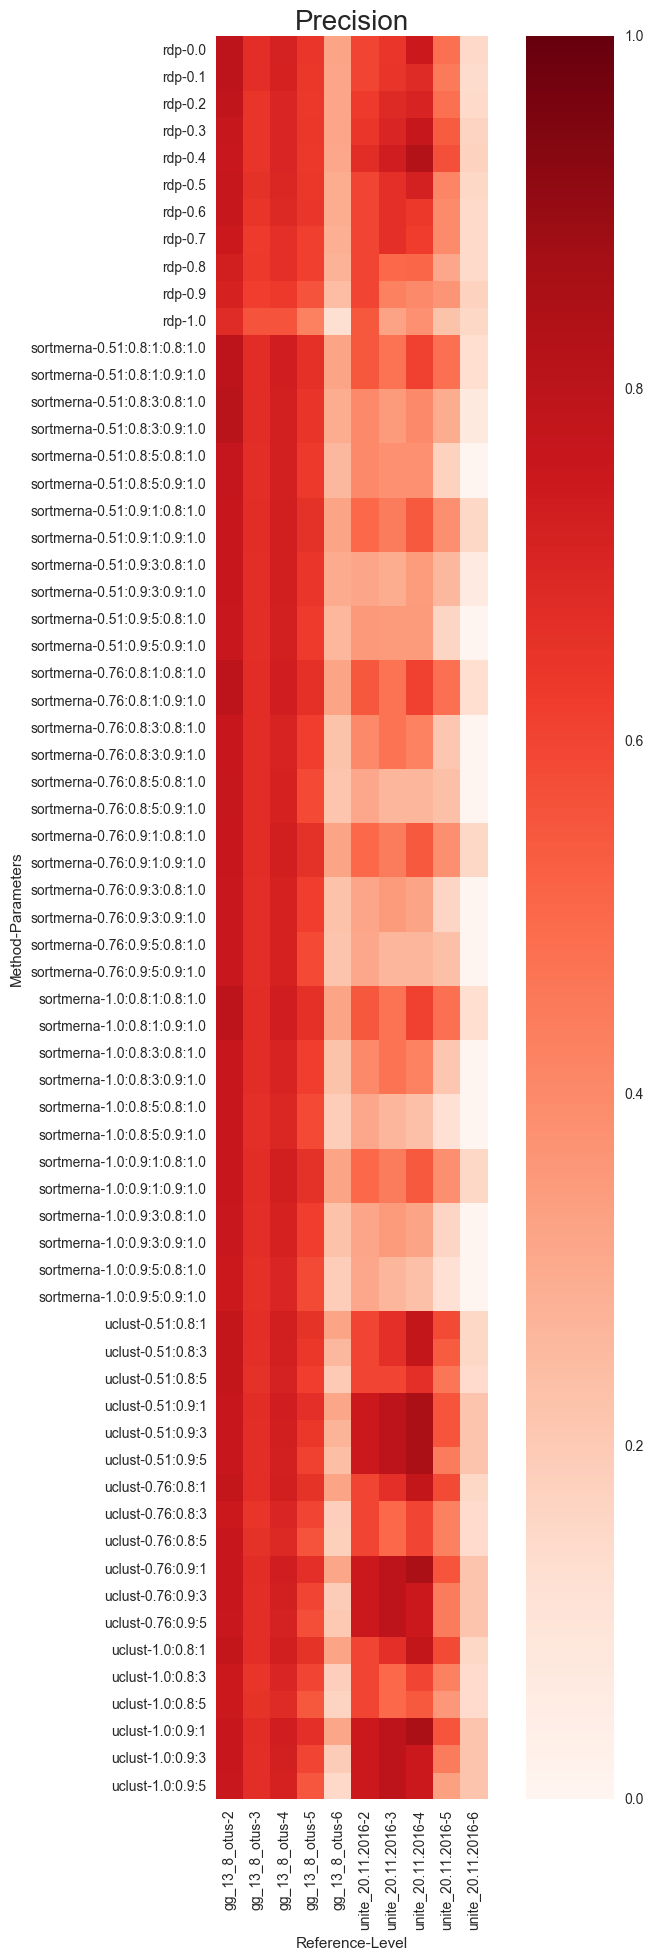

In [42]:
heatmap_from_data_frame(mock_results, metric="Precision", rows=["Method", "Parameters"], cols=["Reference", "Level"])

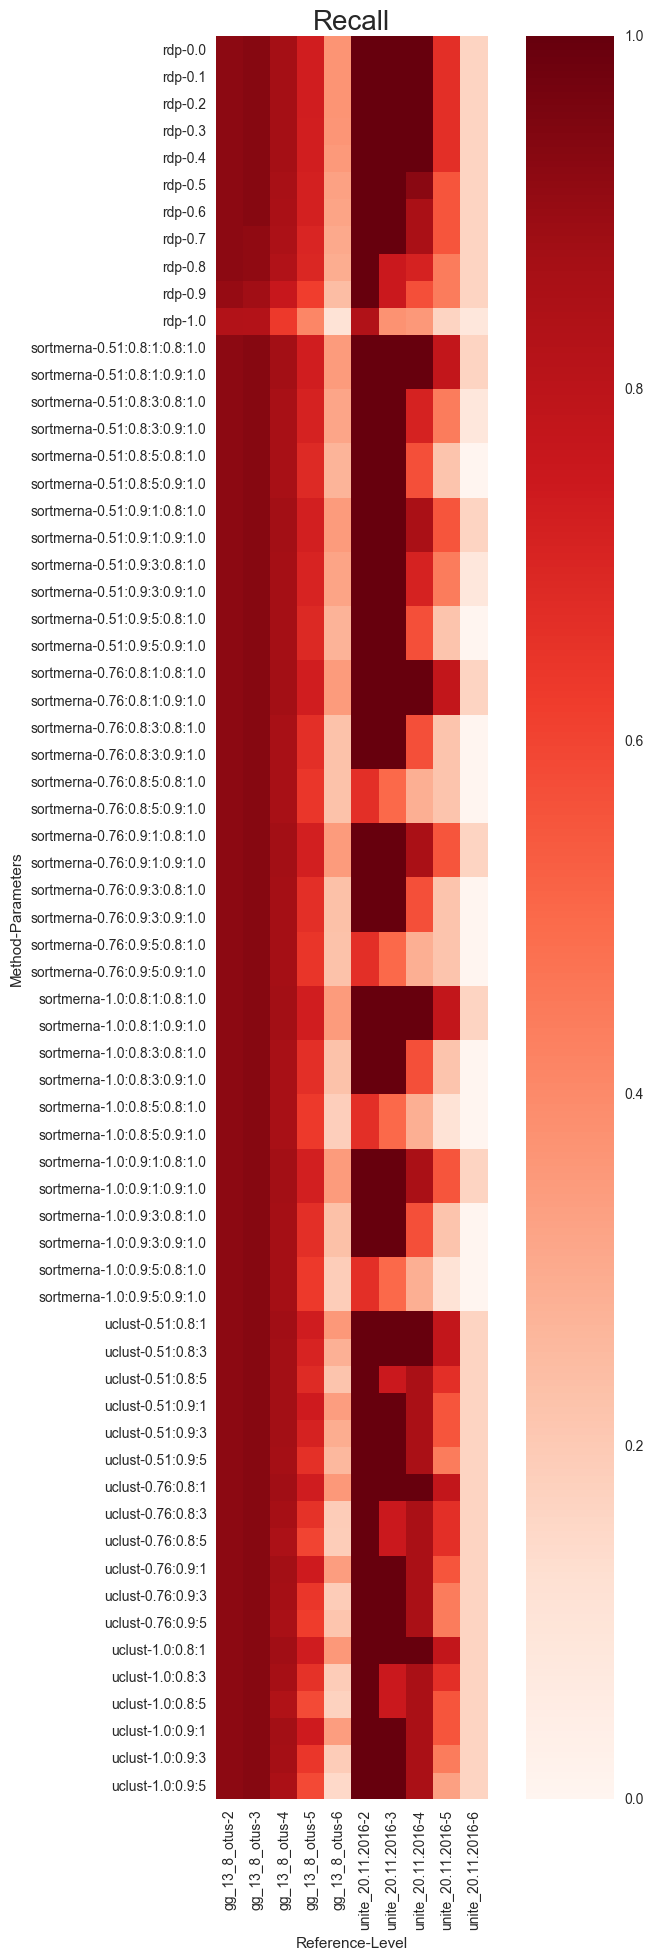

In [17]:
heatmap_from_data_frame(mock_results, metric="Recall", rows=["Method", "Parameters"], cols=["Reference", "Level"])

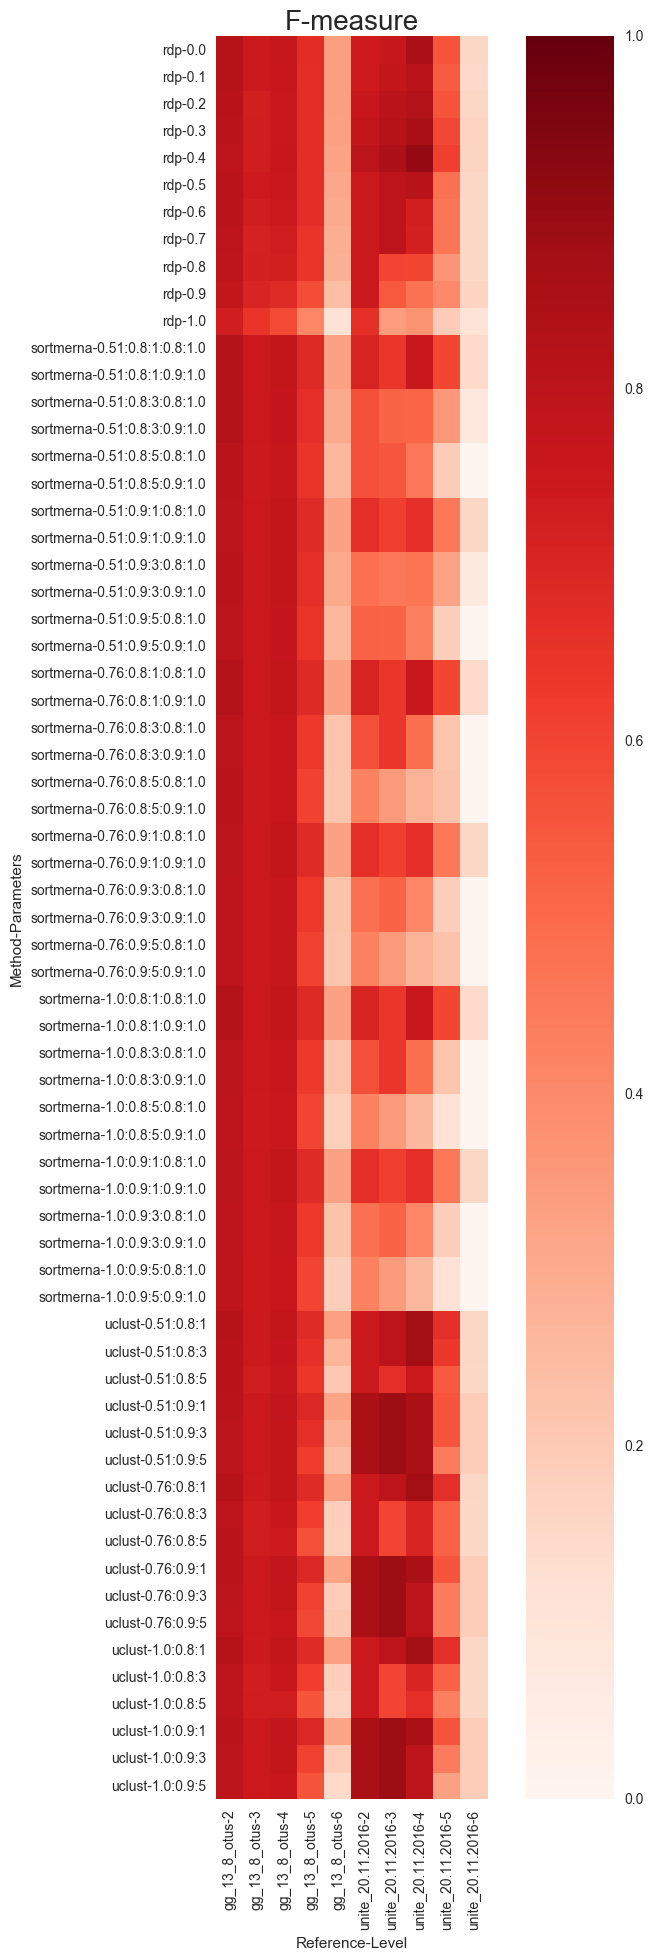

In [18]:
heatmap_from_data_frame(mock_results, metric="F-measure", rows=["Method", "Parameters"], cols=["Reference", "Level"])

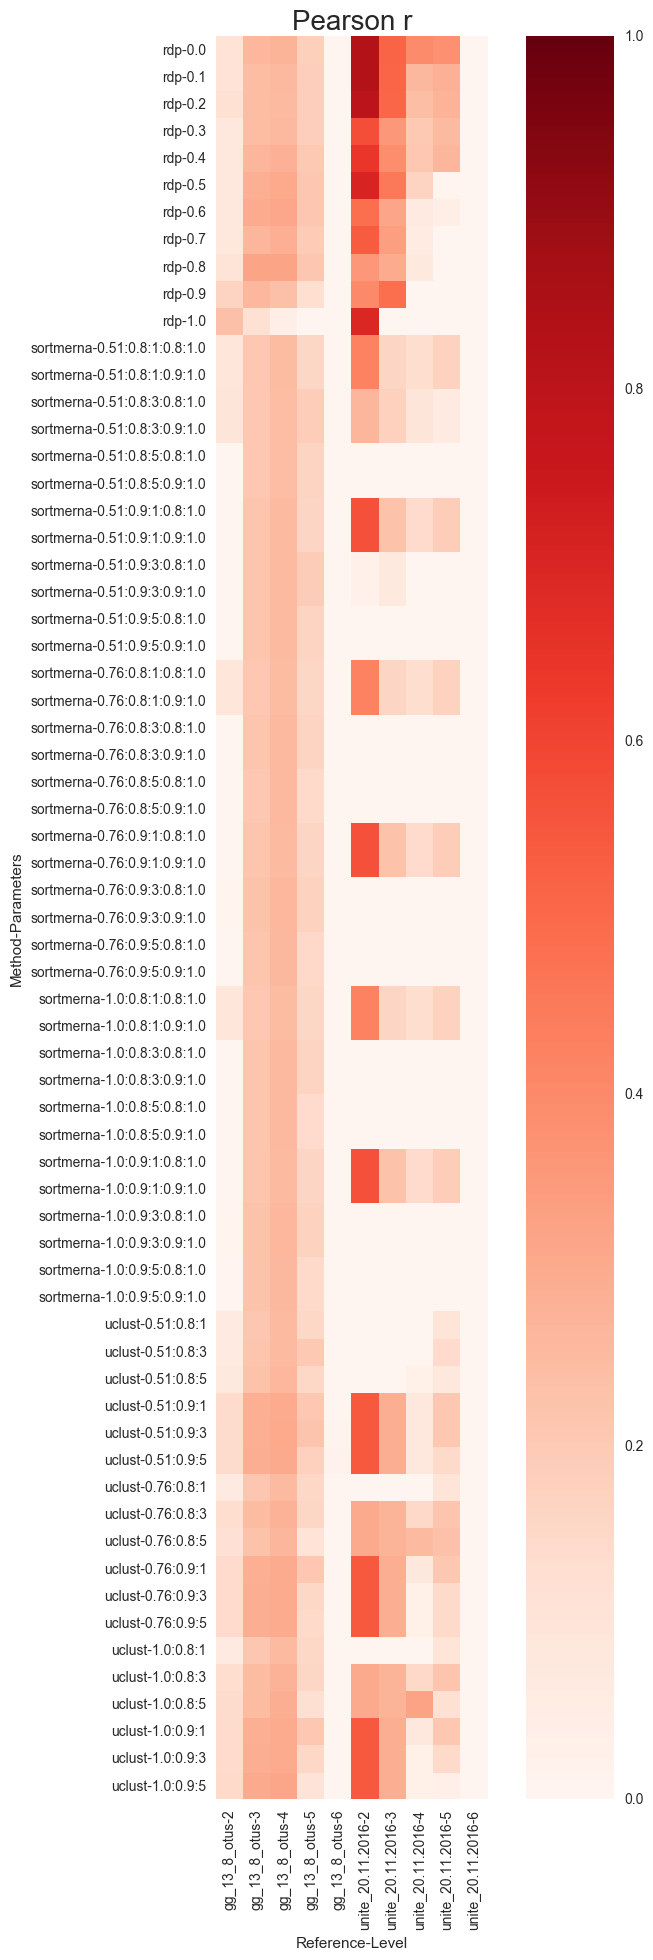

In [19]:
heatmap_from_data_frame(mock_results, metric="Pearson r", rows=["Method", "Parameters"], cols=["Reference", "Level"])

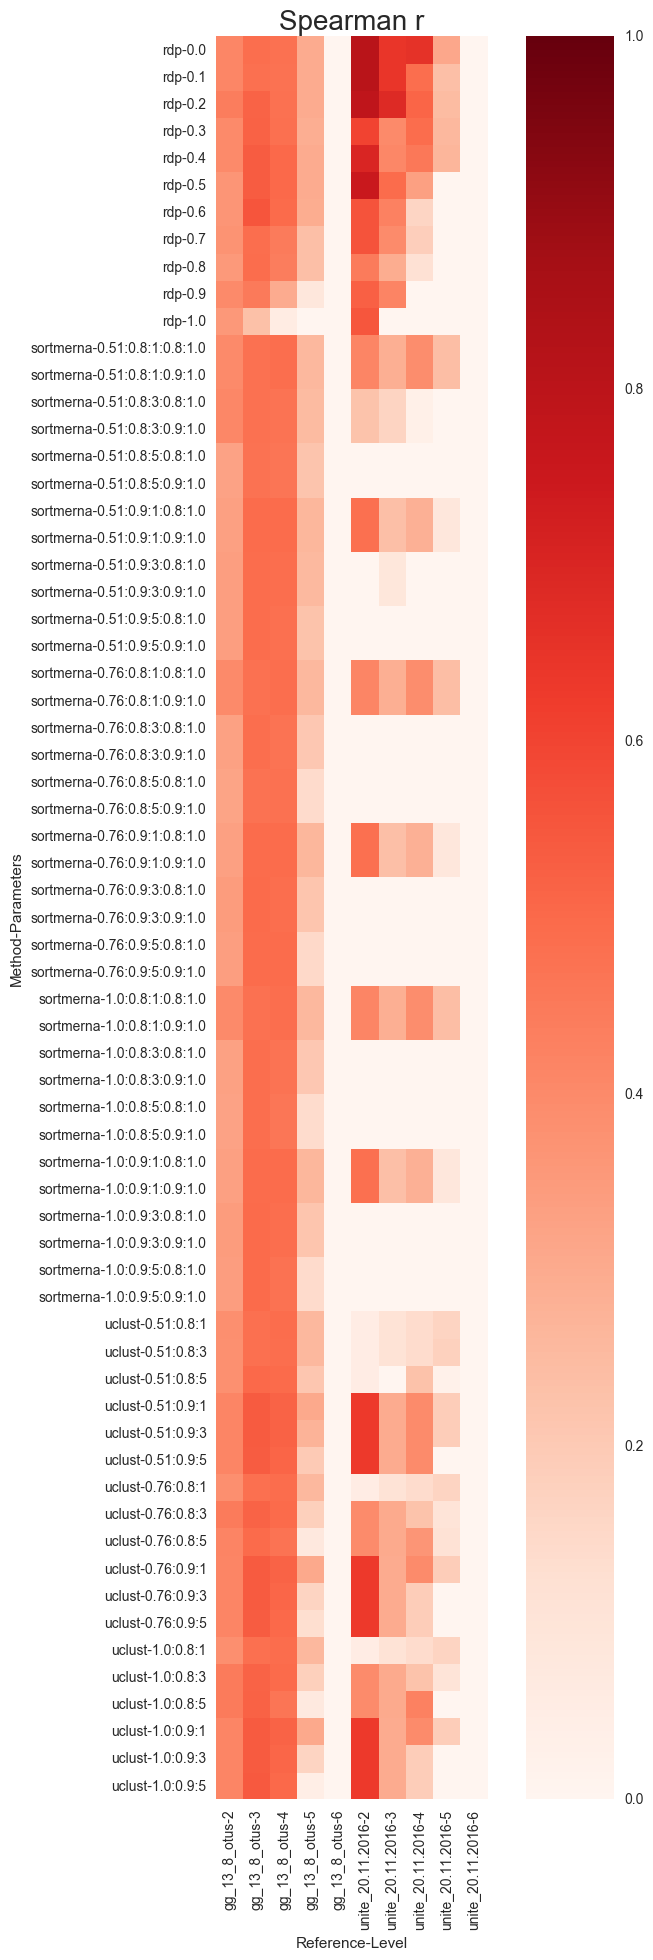

In [20]:
heatmap_from_data_frame(mock_results, metric="Spearman r", rows=["Method", "Parameters"], cols=["Reference", "Level"])

Now we will focus on results at species level (for genus level, change to level 5)

In [21]:
mock_results_6 = mock_results[mock_results['Level'] == 6]

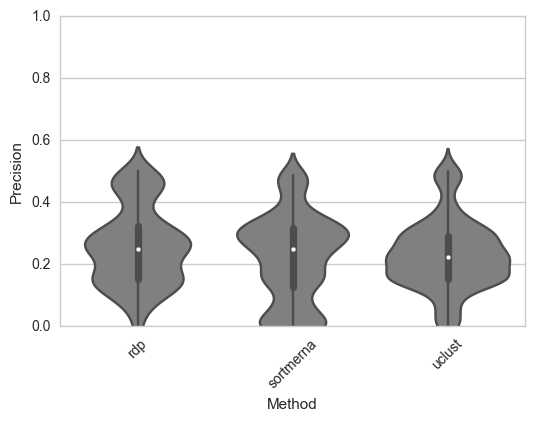

In [22]:
boxplot_from_data_frame(mock_results_6, group_by="Method", metric="Precision")

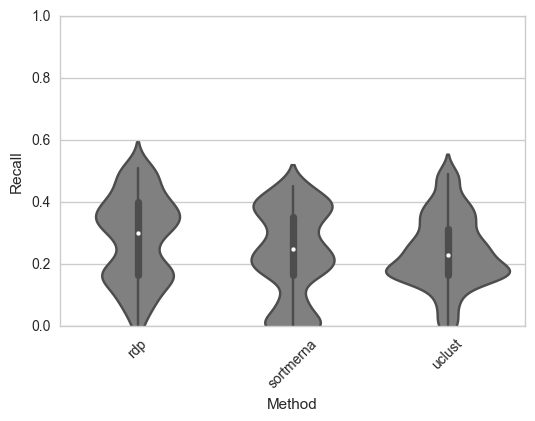

In [23]:
boxplot_from_data_frame(mock_results_6, group_by="Method", metric="Recall")

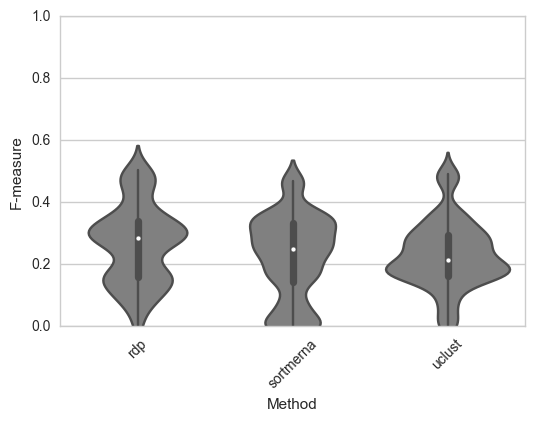

In [24]:
boxplot_from_data_frame(mock_results_6, group_by="Method", metric="F-measure")

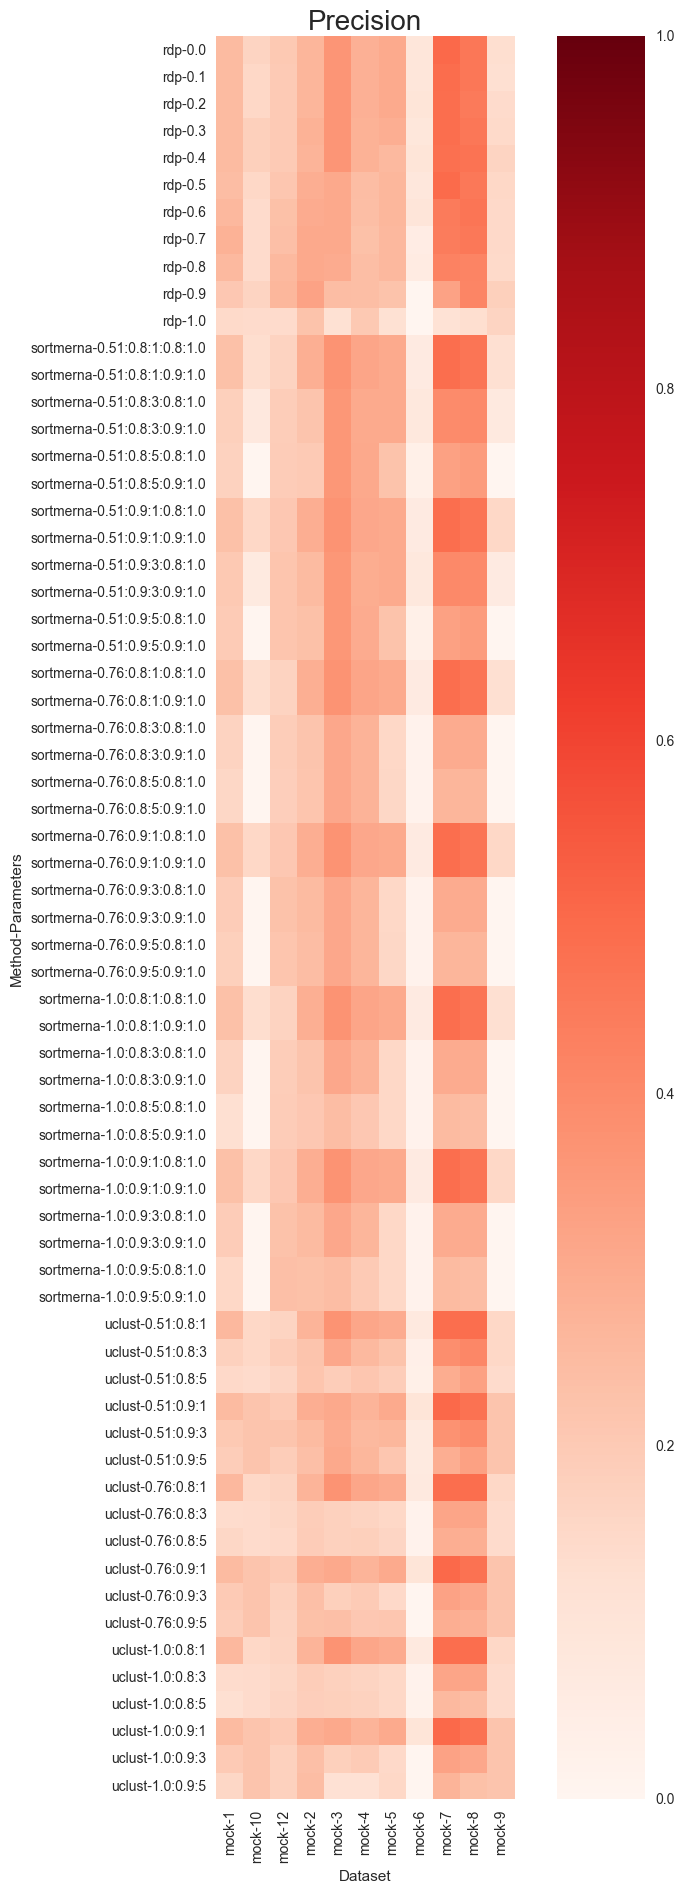

In [25]:
heatmap_from_data_frame(mock_results_6, "Precision")

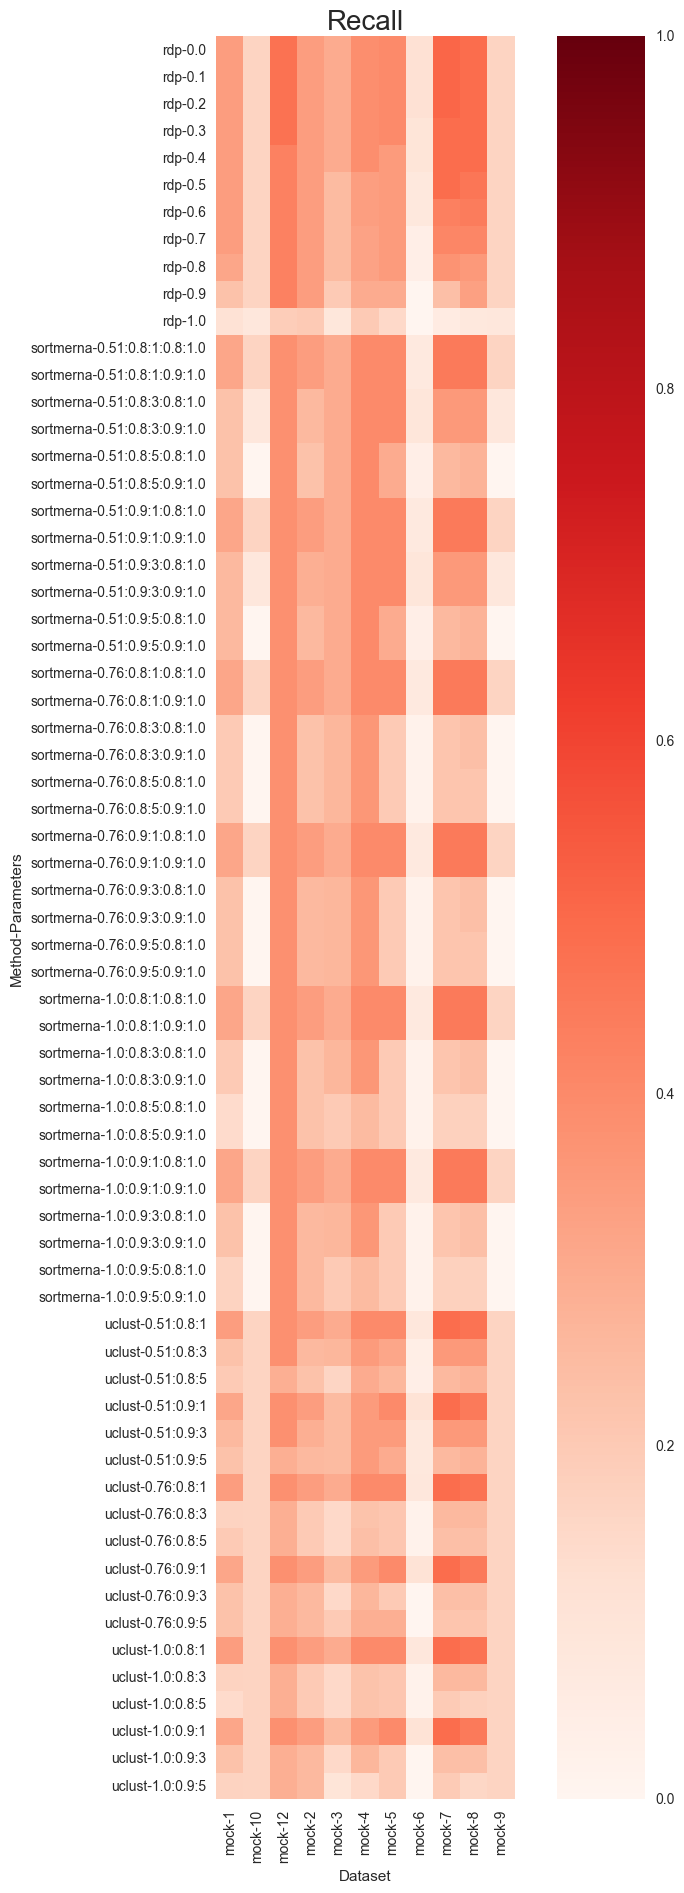

In [26]:
heatmap_from_data_frame(mock_results_6, "Recall")

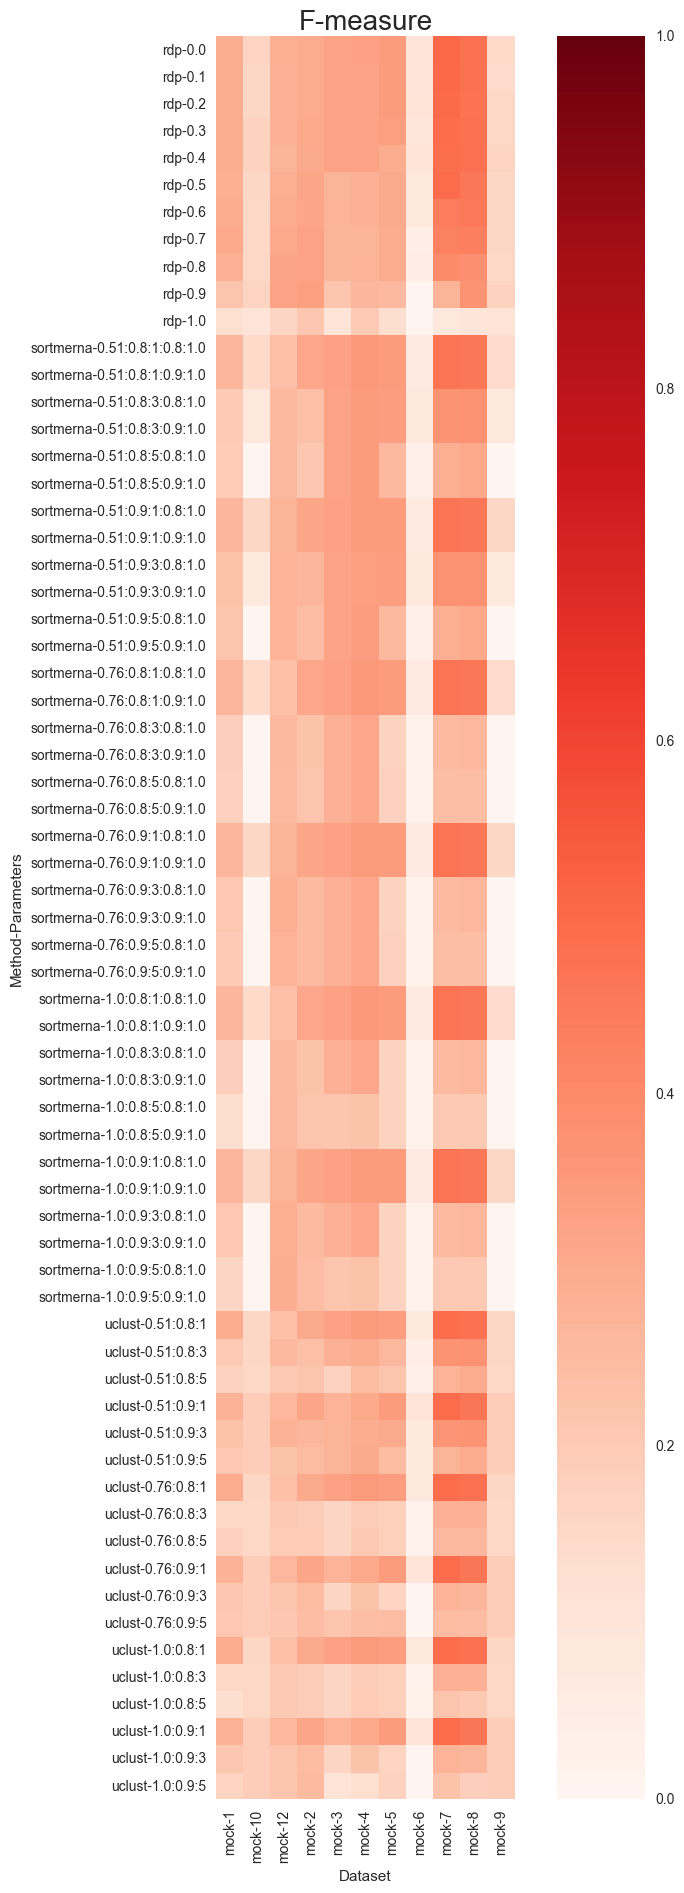

In [27]:
heatmap_from_data_frame(mock_results_6, "F-measure")

In [38]:
for i in range(1,13):
    print('mock-{0}'.format(i))
    best = method_by_dataset_a1(mock_results_6, 'mock-{0}'.format(i))
    display(best)

mock-1


,Method,Precision,Recall,F-measure
39,rdp,0.279070,0.342857,0.307692
269,uclust,0.260870,0.342857,0.296296
214,sortmerna,0.234043,0.314286,0.268293


mock-2


,Method,Precision,Recall,F-measure
1674,rdp,0.324324,0.342857,0.333333
1834,sortmerna,0.292683,0.342857,0.315789
1909,uclust,0.292683,0.342857,0.315789


mock-3


...

,Method,Precision,Recall,F-measure
1299,uclust,0.222222,0.166667,0.190476
382,rdp,0.181818,0.166667,0.173913
954,sortmerna,0.153846,0.166667,0.160000


mock-11


,Method,Precision,Recall,F-measure


mock-12


,Method,Precision,Recall,F-measure
1349,rdp,0.264706,0.428571,0.327273
1534,sortmerna,0.235294,0.380952,0.290909
1559,uclust,0.222222,0.380952,0.280702


In [29]:
for method in mock_results_6['Method'].unique():
    top_params = parameter_comparisons(mock_results_6, method)
    print(method)
    display(top_params[:5])

rdp


,F-measure,Pearson r,Precision,Recall,Spearman r
0.0,25.0,17,21.0,30.0,27
0.1,22.0,17,21.0,30.0,26
0.3,25.0,13,24.0,30.0,25
0.2,22.0,13,21.0,30.0,24
0.4,24.0,15,20.0,25.0,22


sortmerna


,F-measure,Pearson r,Precision,Recall,Spearman r
0.51:0.8:1:0.8:1.0,29.0,25.0,29.0,30,27.0
0.76:0.8:1:0.8:1.0,29.0,25.0,29.0,30,27.0
1.0:0.8:1:0.9:1.0,29.0,25.0,29.0,30,27.0
1.0:0.8:1:0.8:1.0,29.0,25.0,29.0,30,27.0
0.51:0.8:1:0.9:1.0,29.0,25.0,29.0,30,27.0


uclust


,F-measure,Pearson r,Precision,Recall,Spearman r
0.76:0.9:1,30.0,18,29.0,30,29
1.0:0.9:1,30.0,18,29.0,30,29
0.51:0.9:1,30.0,18,29.0,30,29
0.76:0.8:1,22.0,15,22.0,29,22
1.0:0.8:1,22.0,15,22.0,29,22


In [30]:
for dataset in mock_results['Reference'].unique():
    for level in range(4,7):
        method_rank = method_by_dataset(mock_results[mock_results["Level"] == level],
                                        group_by = 'Reference',
                                        dataset=dataset, sort_field="F-measure",
                                        display_fields=("Method", "Precision", "Recall", "F-measure"))
        print("{0} level {1}".format(dataset, level))
        display(method_rank)

gg_13_8_otus level 4


,Method,Precision,Recall,F-measure
2339,sortmerna,0.944444,0.944444,0.944444
3119,uclust,0.944444,0.944444,0.944444
1999,rdp,0.944444,0.944444,0.944444


gg_13_8_otus level 5


,Method,Precision,Recall,F-measure
3083,uclust,0.944444,0.944444,0.944444
2343,sortmerna,0.944444,0.944444,0.944444
2083,rdp,0.944444,0.944444,0.944444


gg_13_8_otus level 6


...

,Method,Precision,Recall,F-measure
331,rdp,0.875000,1.0,0.933333
10016,uclust,0.777778,1.0,0.875000
513,sortmerna,0.636364,1.0,0.777778


unite_20.11.2016 level 5


,Method,Precision,Recall,F-measure
1130,uclust,0.583333,0.777778,0.666667
396,rdp,0.600000,0.666667,0.631579
695,sortmerna,0.500000,0.777778,0.608696


unite_20.11.2016 level 6


,Method,Precision,Recall,F-measure
10189,uclust,0.222222,0.166667,0.190476
384,rdp,0.181818,0.166667,0.173913
9678,sortmerna,0.153846,0.166667,0.160000


Evaluation 2: Compute and summarize correlations between observed and known mock community structure
----------------------------------------------------------------------------------------------------

In this evaluation, we compute and summarize the correlation between each result (pre-computed and query) and the known composition of the mock communities. We then summarize the results in two ways: first with a series of boxplots of correlation coefficients by method; and second with a table of the top methods based on their Pearson correlation coefficient. 

This is a quantitative evaluation, which tells us about the ability of the different methods to report the taxa that are present in each sample and accurately assess their abundance. Because many factors can affect the observed abundance of taxa beyond the accuracy of the taxonomic assigner (e.g., primer bias), the correlation coefficients are frequently low, but we expect that their relative values are informative in understanding which taxonomic assigners are more correct than others.

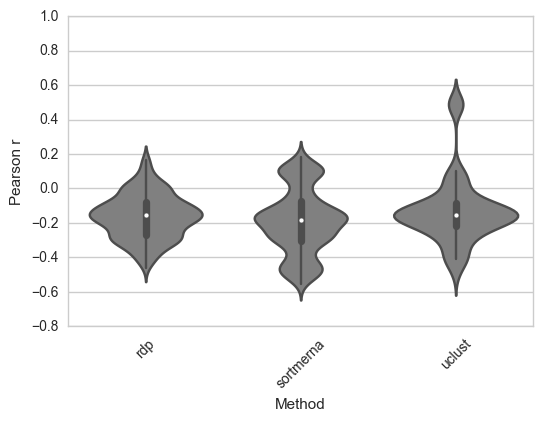

In [31]:
boxplot_from_data_frame(mock_results_6, group_by="Method", metric="Pearson r", y_min=None)

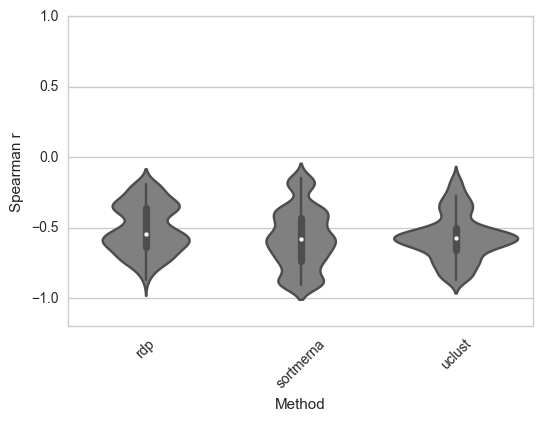

In [32]:
boxplot_from_data_frame(mock_results_6, group_by="Method", metric="Spearman r", y_min=None)

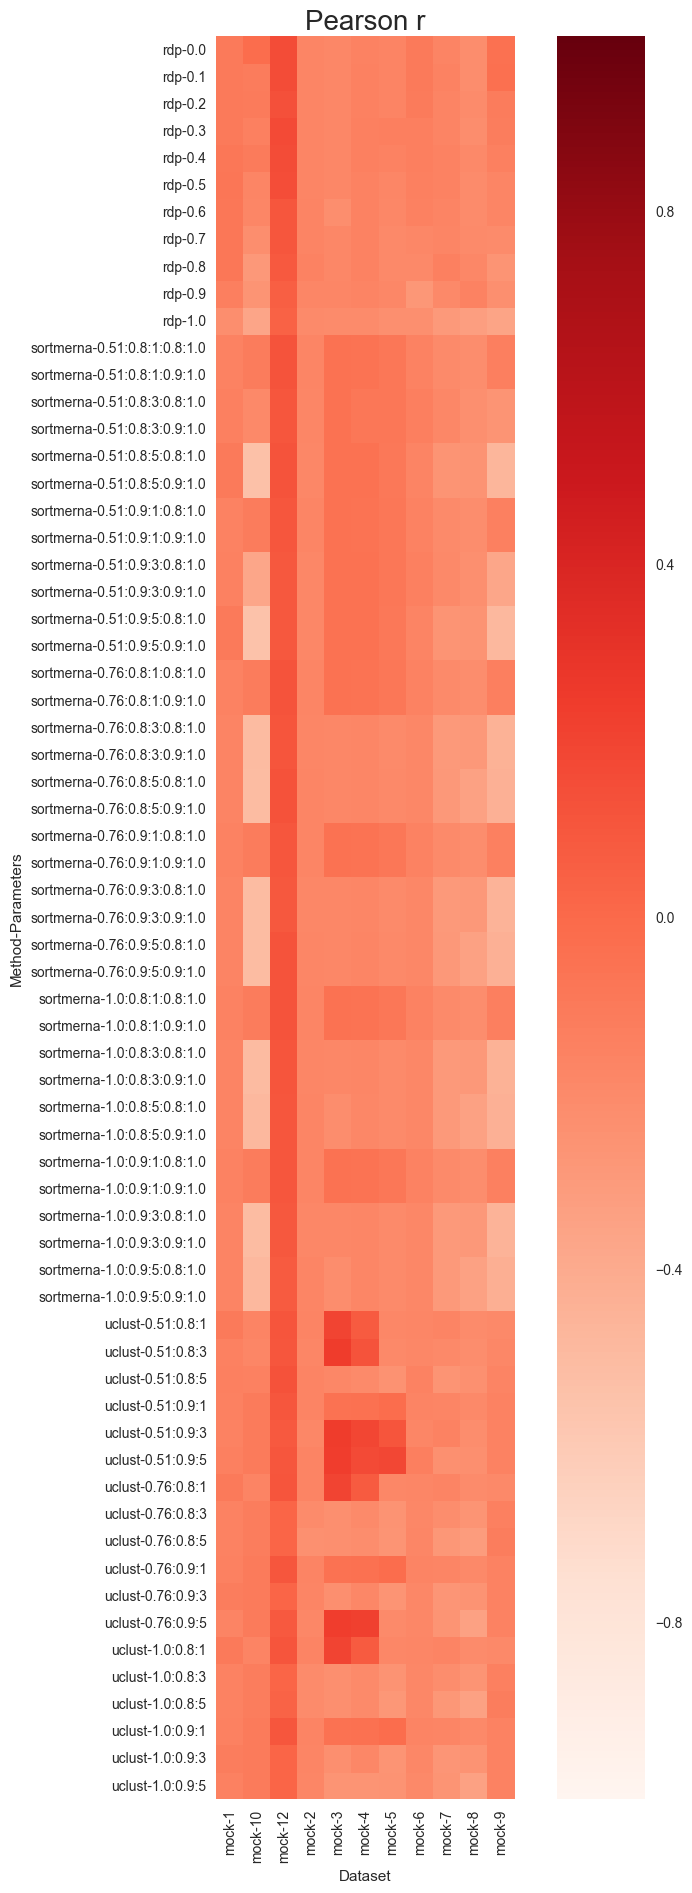

In [33]:
heatmap_from_data_frame(mock_results_6, "Pearson r", vmin=-1, vmax=1)

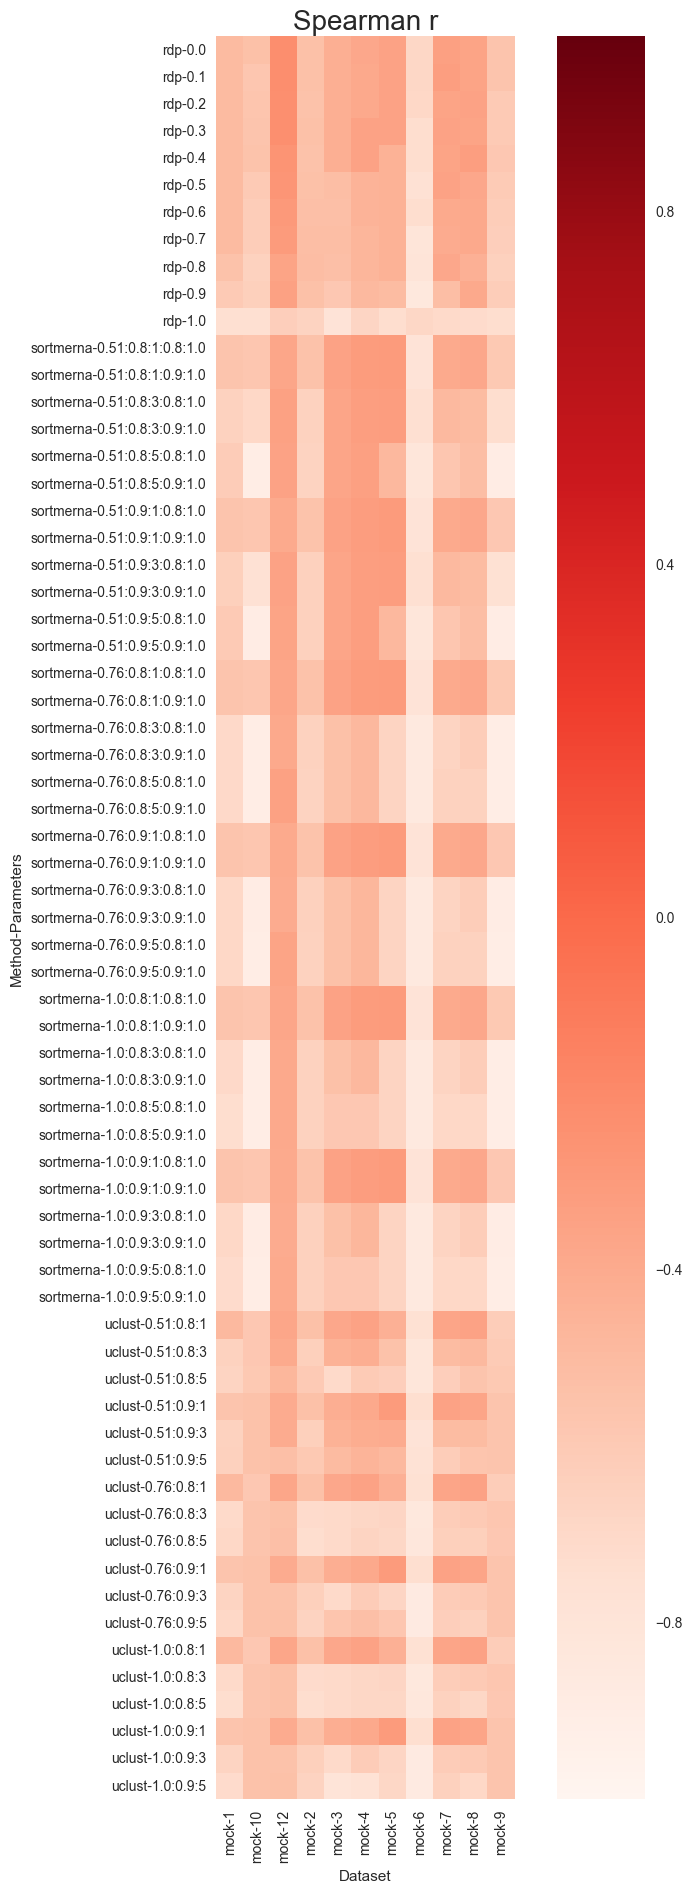

In [34]:
heatmap_from_data_frame(mock_results_6, "Spearman r", vmin=-1, vmax=1)

In [35]:
for i in range(1,11):
    print('mock-{0}'.format(i))
    best = method_by_dataset_a2(mock_results_6, 'mock-{0}'.format(i))
    display(best)

mock-1


,Method,Pearson r,Spearman r
29,rdp,-0.077968,-0.496182
84,sortmerna,-0.096606,-0.610318
239,uclust,-0.097287,-0.487643


mock-2


,Method,Pearson r,Spearman r
1669,rdp,-0.154272,-0.515470
1939,uclust,-0.158954,-0.537265
1804,sortmerna,-0.164660,-0.546716


mock-3


...

,Method,Pearson r,Spearman r
8387,rdp,-0.136283,-0.377789
9093,uclust,-0.175675,-0.365281
8598,sortmerna,-0.197973,-0.376334


mock-9


,Method,Pearson r,Spearman r
9228,rdp,-0.013854,-0.552881
10054,uclust,-0.103205,-0.536776
9754,sortmerna,-0.126393,-0.596489


mock-10


,Method,Pearson r,Spearman r
337,rdp,0.016503,-0.509773
1163,uclust,-0.067815,-0.554392
788,sortmerna,-0.094590,-0.573749


In [36]:
for dataset in mock_results['Reference'].unique():
    for level in range(4,7):
        method_rank = method_by_dataset(mock_results[mock_results["Level"] == level],
                                        group_by = 'Reference',
                                        dataset=dataset, sort_field="Pearson r",
                                        display_fields=("Method", "Pearson r", "Spearman r"))
        print("{0} level {1}".format(dataset, level))
        display(method_rank)

gg_13_8_otus level 4


,Method,Pearson r,Spearman r
6296,rdp,0.643840,0.432976
4261,sortmerna,0.641556,0.836632
4761,uclust,0.627270,0.832903


gg_13_8_otus level 5


,Method,Pearson r,Spearman r
4665,uclust,0.856830,0.760183
3985,sortmerna,0.810922,0.779260
5165,rdp,0.588838,0.774619


gg_13_8_otus level 6


...

,Method,Pearson r,Spearman r
9222,rdp,0.504201,0.800656
1247,uclust,0.418344,0.482569
9402,sortmerna,0.188462,0.407168


unite_20.11.2016 level 5


,Method,Pearson r,Spearman r
334,rdp,0.459601,0.379745
1160,uclust,0.279141,0.120126
771,sortmerna,0.220474,0.066383


unite_20.11.2016 level 6


,Method,Pearson r,Spearman r
337,rdp,0.016503,-0.509773
1163,uclust,-0.067815,-0.554392
968,sortmerna,-0.094590,-0.573749
